# Lab 5 - Evaluation methods


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_curve,
    roc_curve, auc
)


## Setup

We use two binary classification datasets:

1. Real data: `load_breast_cancer`.
2. Artificial data: `x ~ N(0, I)`, `beta=(b,b,b,b,b,0,...,0)`, and
   `P(Y=1|x)=sigmoid(alpha + beta.T @ x)`.

Increasing `alpha` shifts all logits upward, so `P(Y=1)` increases and the dataset becomes imbalanced toward class 1. The expected class proportion is `E[sigmoid(alpha + beta.T X)]`, estimated below by Monte Carlo because the logistic-normal integral has no simple closed form.

Logistic regression is expected to be more stable under repeated sampling when the true boundary is smooth and approximately linear. A tree is more adaptive but higher variance.


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def make_artificial(n=1000, b=1.0, k=20, alpha=1.0, random_state=42):
    local_rng = np.random.default_rng(random_state)
    p = 5 + k
    X = local_rng.normal(size=(n, p))
    beta = np.r_[np.repeat(b, 5), np.zeros(k)]
    prob = sigmoid(alpha + X @ beta)
    y = local_rng.binomial(1, prob)
    return X, y, prob


for alpha in [0, 1, 2]:
    _, y_tmp, prob_tmp = make_artificial(alpha=alpha, random_state=alpha + 10)
    print(f"alpha={alpha}: sample proportion={y_tmp.mean():.3f}, Monte Carlo E[P(Y=1)]={prob_tmp.mean():.3f}")


alpha=0: sample proportion=0.481, Monte Carlo E[P(Y=1)]=0.491
alpha=1: sample proportion=0.646, Monte Carlo E[P(Y=1)]=0.637
alpha=2: sample proportion=0.744, Monte Carlo E[P(Y=1)]=0.760


## Task 1 - refit, 10-fold CV, bootstrap, and bootstrap 0.632


In [3]:
def misclassification_error(model, X_train, y_train, X_test, y_test):
    model = clone(model).fit(X_train, y_train)
    return 1 - accuracy_score(y_test, model.predict(X_test))


def evaluation_estimates(model, X, y, n_bootstrap=100, random_state=42):
    local_rng = np.random.default_rng(random_state)
    n = len(y)
    refit = misclassification_error(model, X, y, X, y)
    cv = 1 + cross_val_score(model, X, y, cv=KFold(10, shuffle=True, random_state=random_state), scoring="accuracy").mean() * -1

    boot_oob = []
    boot_632 = []
    for _ in range(n_bootstrap):
        train_idx = local_rng.integers(0, n, size=n)
        in_bag = np.zeros(n, dtype=bool)
        in_bag[train_idx] = True
        oob_idx = np.where(~in_bag)[0]
        if len(oob_idx) == 0:
            continue
        app = misclassification_error(model, X[train_idx], y[train_idx], X[train_idx], y[train_idx])
        oob = misclassification_error(model, X[train_idx], y[train_idx], X[oob_idx], y[oob_idx])
        boot_oob.append(oob)
        boot_632.append(0.368 * app + 0.632 * oob)

    return {
        "refit": refit,
        "10-fold CV": cv,
        "bootstrap OOB": float(np.mean(boot_oob)),
        "bootstrap .632": float(np.mean(boot_632)),
    }


X, y, _ = make_artificial(n=1000, b=1, k=20, alpha=1, random_state=RANDOM_STATE)
models = {
    "logistic": LogisticRegression(max_iter=2000),
    "tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

for model_name, model in models.items():
    print(model_name, evaluation_estimates(model, X, y, n_bootstrap=80))


logistic {'refit': 0.19099999999999995, '10-fold CV': np.float64(0.20699999999999996), 'bootstrap OOB': 0.21122718987960093, 'bootstrap .632': 0.19920198400390782}
tree {'refit': 0.0, '10-fold CV': np.float64(0.29500000000000004), 'bootstrap OOB': 0.32163784134478457, 'bootstrap .632': 0.20327511572990384}


Refitting is usually the most optimistic because it tests on data already used for training. Cross-validation and out-of-bag bootstrap estimate generalization more honestly. The 0.632 bootstrap mixes apparent and OOB error, often reducing the pessimism of pure OOB estimates.


## Task 2 - ROC and precision-recall curves under class imbalance


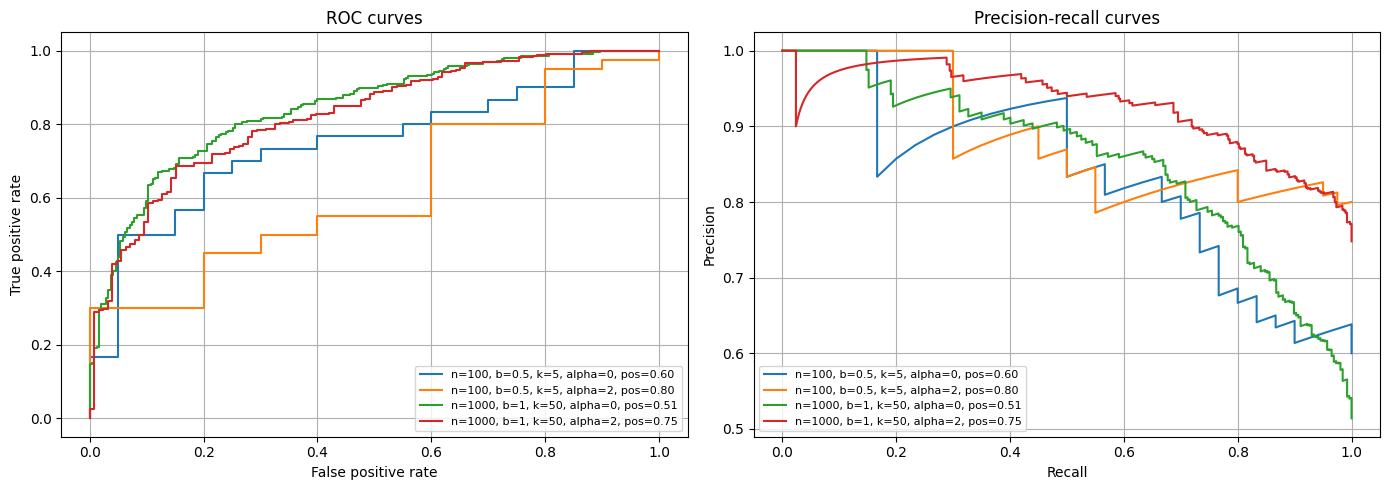

In [4]:
def plot_roc_pr_for_setting(n, b, k, alpha, ax_roc, ax_pr):
    X, y, _ = make_artificial(n=n, b=b, k=k, alpha=alpha, random_state=RANDOM_STATE + int(10 * alpha) + n + k)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, stratify=y, random_state=RANDOM_STATE)
    clf = LogisticRegression(max_iter=2000).fit(X_train, y_train)
    scores = clf.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, scores)
    precision, recall, _ = precision_recall_curve(y_val, scores)
    label = f"n={n}, b={b}, k={k}, alpha={alpha}, pos={y_val.mean():.2f}"
    ax_roc.plot(fpr, tpr, label=label)
    ax_pr.plot(recall, precision, label=label)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for params in [(100, 0.5, 5, 0), (100, 0.5, 5, 2), (1000, 1, 50, 0), (1000, 1, 50, 2)]:
    plot_roc_pr_for_setting(*params, ax_roc=axes[0], ax_pr=axes[1])
axes[0].set_title("ROC curves")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[1].set_title("Precision-recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
for ax in axes:
    ax.grid(True)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Precision-recall is more informative when `alpha=2`, because the positive class becomes more common and threshold choices change precision directly. More generally, PR curves are especially useful when the class of interest is rare or when false positives are costly.


## Task 3 - threshold-dependent accuracy and balanced accuracy


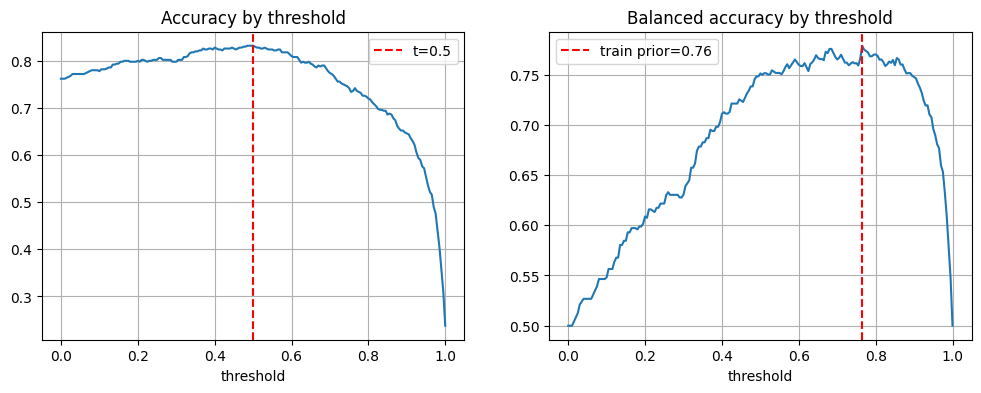

In [5]:
X, y, _ = make_artificial(n=1000, b=1, k=20, alpha=2, random_state=7)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, stratify=y, random_state=RANDOM_STATE)
clf = LogisticRegression(max_iter=2000).fit(X_train, y_train)
scores = clf.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0, 1, 201)
acc = [accuracy_score(y_val, scores > t) for t in thresholds]
bal = [balanced_accuracy_score(y_val, scores > t) for t in thresholds]
prior_threshold = y_train.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thresholds, acc)
axes[0].axvline(0.5, color="red", linestyle="--", label="t=0.5")
axes[0].set_title("Accuracy by threshold")
axes[1].plot(thresholds, bal)
axes[1].axvline(prior_threshold, color="red", linestyle="--", label=f"train prior={prior_threshold:.2f}")
axes[1].set_title("Balanced accuracy by threshold")
for ax in axes:
    ax.set_xlabel("threshold")
    ax.grid(True)
    ax.legend()
plt.show()


Accuracy often peaks near 0.5 when classes and costs are balanced. Balanced accuracy compensates for class prevalence, so the optimum can move toward the empirical prior. If false positives and false negatives have different costs, the optimal threshold should move toward the class whose mistakes are more expensive to avoid.
